In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [92]:
df = pd.read_csv(r'C:\Users\rbhalla\Desktop\credit-risk-model\data\loan_data.csv')
df.head()

C:\Users\rbhalla\AppData\Local\Temp\ipykernel_32912\3621714716.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\rbhalla\Desktop\credit-risk-model\data\loan_data.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
df['default'] = df['loan_status'].isin([
    'Charged Off', 'Default', 'Late (31-120 days)'
]).astype(int)

df['default'].value_counts(normalize=True)

default
0    0.871692
1    0.128308
Name: proportion, dtype: float64

In [96]:
df = df[['loan_amnt','int_rate','annual_inc','dti','grade','loan_status','default']]

df = df[['loan_amnt','int_rate','annual_inc','dti','grade','loan_status','default']]

df = df.dropna()

In [98]:
df['int_rate'] = (
    df['int_rate']
    .astype(str)
    .str.replace('%', '', regex=False)
)

df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')

In [100]:
grade_map = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}
df['grade_num'] = df['grade'].map(grade_map)

In [102]:
df = df.drop(columns=['grade', 'grade_num'])

In [104]:
X = df[['loan_amnt','int_rate','annual_inc','dti']]
y = df['default']

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [108]:
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [110]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [112]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

pd_pred = model.predict_proba(X_test)[:,1]

In [114]:
auc = roc_auc_score(y_test, pd_pred)
print("AUC:", auc)

AUC: 0.6800508697263685


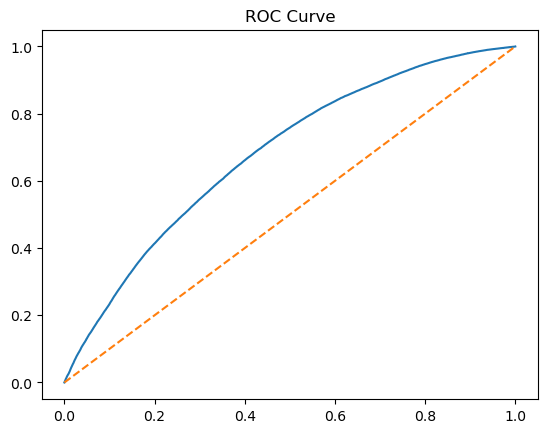

In [116]:
fpr, tpr, _ = roc_curve(y_test, pd_pred)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

In [118]:
df['PD'] = model.predict_proba(
    scaler.transform(imputer.transform(X))
)[:,1]

In [120]:
df['LGD'] = 0.6
df['EAD'] = df['loan_amnt']

In [122]:
df['EL'] = df['PD'] * df['LGD'] * df['EAD']

df[['PD','LGD','EAD','EL']].head()

,PD,LGD,EAD,EL
0,0.486791,0.6,3600.0,1051.468172
1,0.445979,0.6,24700.0,6609.416168
2,0.402087,0.6,20000.0,4825.039650
3,0.523883,0.6,35000.0,11001.543619
4,0.727590,0.6,10400.0,4540.160684


In [124]:
df['risk_bucket'] = pd.qcut(df['PD'], 10, labels=False)

df.groupby('risk_bucket')['default'].mean()

risk_bucket
0    0.028018
1    0.050692
2    0.073053
3    0.085111
4    0.110643
5    0.134799
6    0.150139
7    0.170606
8    0.218012
9    0.262007
Name: default, dtype: float64

In [126]:
coef = pd.DataFrame({
    'feature': ['loan_amnt','int_rate','annual_inc','dti'],
    'coef': model.coef_[0]
}).sort_values(by='coef', ascending=False)

coef

,feature,coef
1,int_rate,0.612305
0,loan_amnt,0.039223
3,dti,0.028885
2,annual_inc,-0.256109


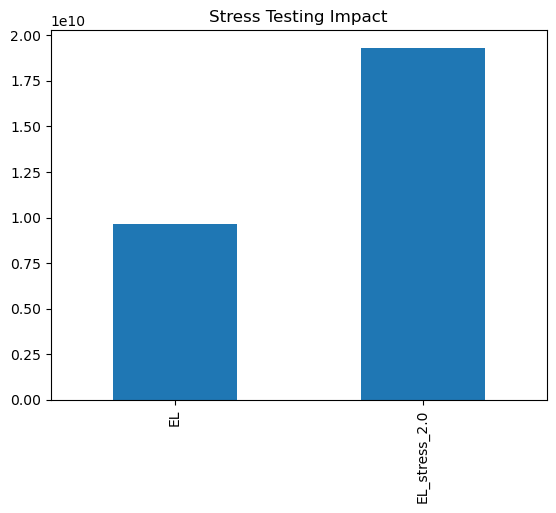

In [128]:
stress_levels = [1.2, 1.5, 2.0]

for s in stress_levels:
    df[f'EL_stress_{s}'] = (df['PD'] * s) * df['LGD'] * df['EAD']

df[['EL','EL_stress_2.0']].sum().plot(kind='bar')
plt.title("Stress Testing Impact")
plt.show()